This problem has the following inputs:
1. Frequency, in Hertzs.
2. Angle of attack, in degrees.
3. Chord length, in meters.
4. Free-stream velocity, in meters per second.
5. Suction side displacement thickness, in meters.

The only output is:
6. Scaled sound pressure level, in decibels.

In [43]:
import pandas as pd
import numpy as np

In [44]:
df  = pd.read_csv('airfoil_self_noise.dat',sep="\t",header=None)

In [45]:
df.head()

,0,1,2,3,4,5
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [46]:
df.columns=["Frequency","Angle of attack","Chord length","Free-stream velocity","Suction side","pressure level"]

In [47]:
df.head()

,Frequency,Angle of attack,Chord length,Free-stream velocity,Suction side,pressure level
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [48]:
df.isnull().sum()

Frequency               0
Angle of attack         0
Chord length            0
Free-stream velocity    0
Suction side            0
pressure level          0
dtype: int64

In [49]:
X = df.drop(columns='pressure level')
y = df['pressure level']

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

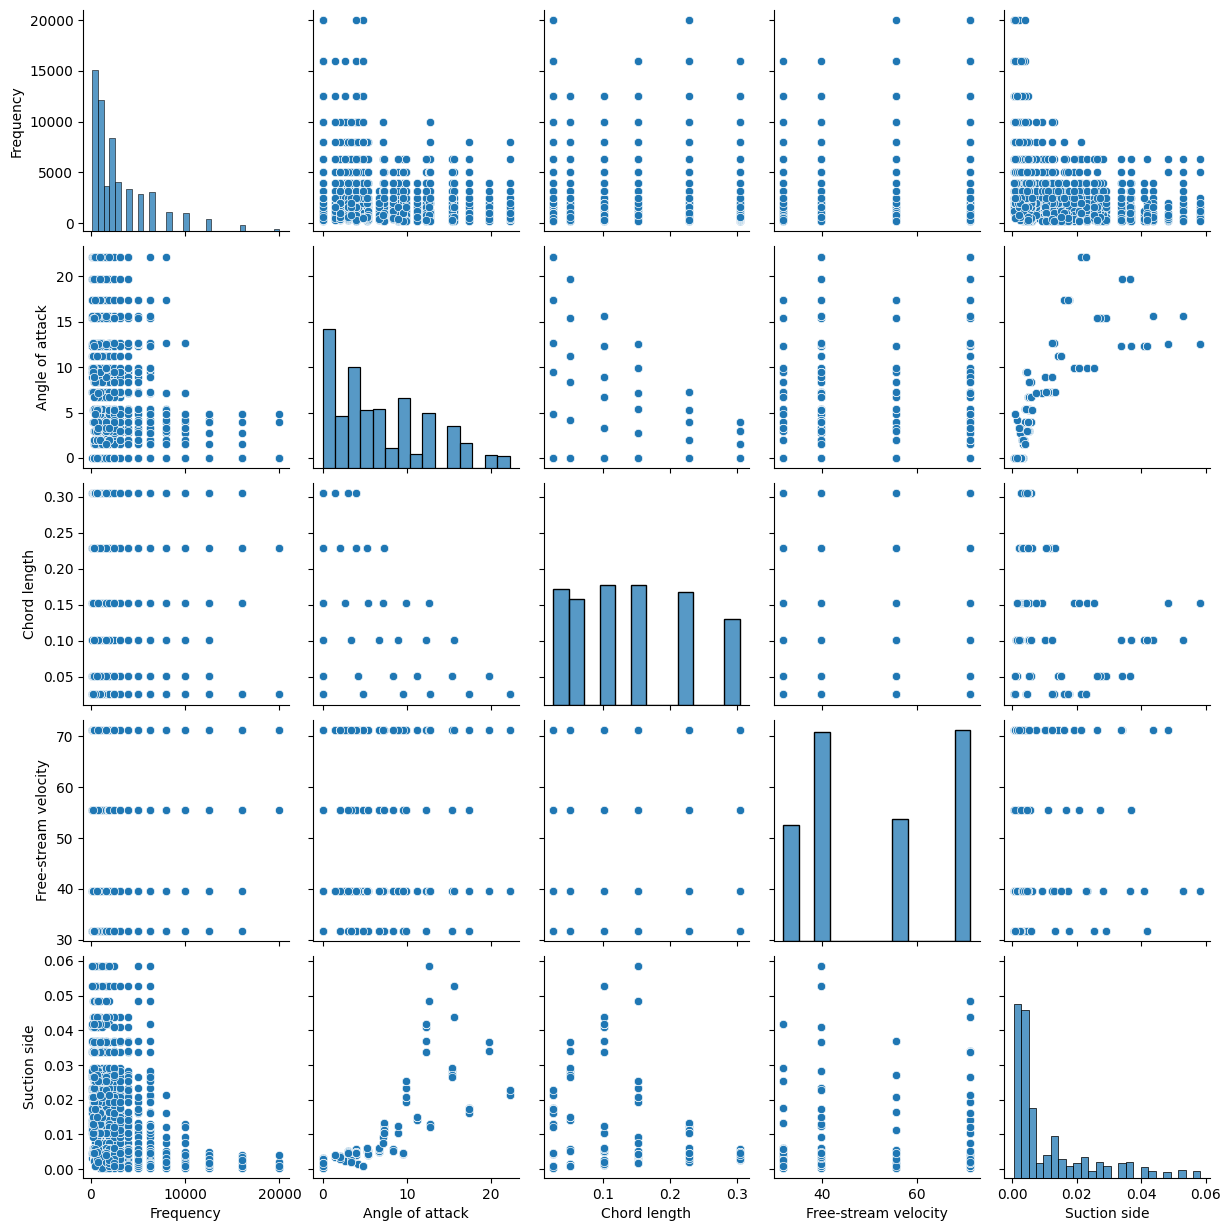

In [51]:
import seaborn as sns
sns.pairplot(X_train)

In [52]:
import matplotlib.pyplot as plt
X_train.corr()

,Frequency,Angle of attack,Chord length,Free-stream velocity,Suction side
Frequency,1.000000,-0.279410,0.012930,0.137387,-0.233708
Angle of attack,-0.279410,1.000000,-0.507163,0.050670,0.760036
Chord length,0.012930,-0.507163,1.000000,0.005318,-0.226070
Free-stream velocity,0.137387,0.050670,0.005318,1.000000,0.003225
Suction side,-0.233708,0.760036,-0.226070,0.003225,1.000000


<Axes: ylabel='Frequency'>

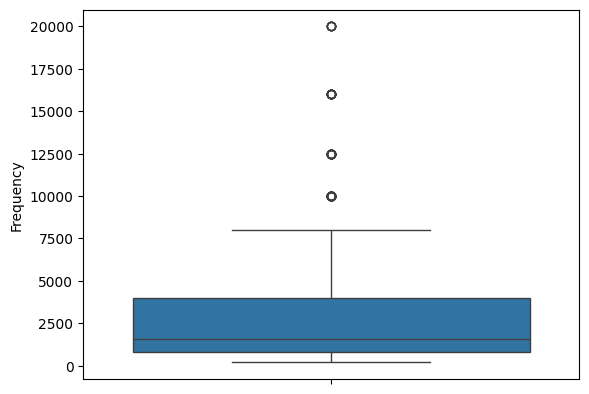

In [53]:
sns.boxplot(X_train['Frequency'])

<Axes: xlabel='Frequency', ylabel='pressure level'>

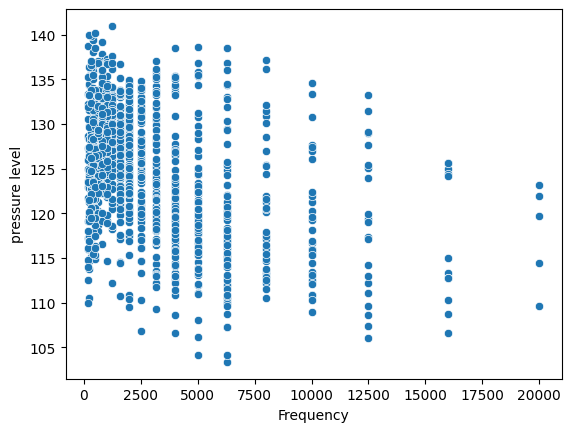

In [54]:
sns.scatterplot(x=X_train['Frequency'], y=y_train)

In [55]:
len(df['pressure level'].unique())

1456

<Axes: ylabel='pressure level'>

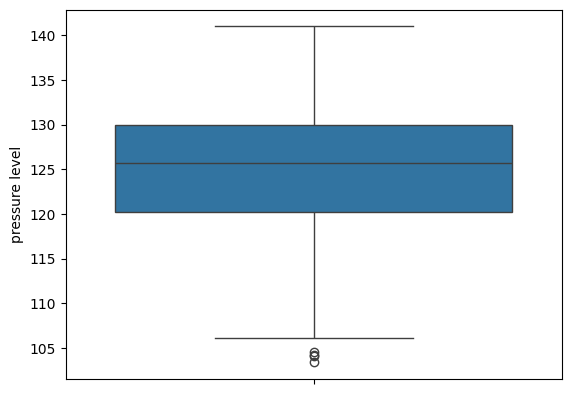

In [56]:
sns.boxplot(df['pressure level'])

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,root_mean_squared_error

In [58]:
linear = LinearRegression()
linear.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred = linear.predict(X_test)
print("Mean Sqaured error", mean_squared_error(y_test, y_pred))
print("Root mean Sqaured Error", root_mean_squared_error(y_test, y_pred))
print("R2 Score", r2_score(y_test, y_pred))
# Accuracy is not applicable for regression tasks


Mean Sqaured error 22.128643318247352
Root mean Sqaured Error 4.704109194974895
R2 Score 0.558297975489727


### Lasso 

In [67]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso = Lasso(max_iter=1000)
params = {"alpha":[0.0001, 0.001, 0.01, 0.1, 1, 10]}
lasso_regression = GridSearchCV(lasso,param_grid=params,cv=5)
lasso_regression.fit(X_train,y_train)
lasso_predicted = lasso_regression.predict(X_test)
r2_score(y_test,lasso_predicted)

0.5581090834357036

### Rigde

In [69]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()

# Define the grid of alpha values to search.
# Alpha controls the strength of the regularization.
# Larger alpha = stronger regularization.
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Use GridSearchCV to find the best alpha through 5-fold cross-validation
# cv=5 means the training data will be split into 5 parts, and the model
# will be trained 5 times, each time using a different part as the validation set.
grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5,
                           scoring='neg_mean_squared_error', verbose=1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best alpha value found
best_alpha = grid_search.best_params_['alpha']
print(f"--- Best Alpha Found ---")
print(f"The optimal alpha value is: {best_alpha}\n")

# Use the best model found by the grid search
model = grid_search.best_estimator_

# Print the model's coefficients and intercept
print("--- Model Coefficients (with Ridge Regularization) ---")
print(f"Intercept: {model.intercept_}")
coeffs = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeffs)
print("\n")


# Step 6: Evaluate the Model

# Make predictions on the test data using the best model
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("--- Ridge Model Evaluation ---")
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Fitting 5 folds for each of 7 candidates, totalling 35 fits
--- Best Alpha Found ---
The optimal alpha value is: 0.001

--- Model Coefficients (with Ridge Regularization) ---
Intercept: 132.5387681620582
                        Coefficient
frequency                 -0.001272
angle_of_attack           -0.409021
chord_length             -34.517897
free_stream_velocity       0.098084
suction_side_thickness  -137.723139


--- Ridge Model Evaluation ---
Mean Absolute Error (MAE): 3.67
Mean Squared Error (MSE): 22.14
Root Mean Squared Error (RMSE): 4.71
R-squared (R²): 0.56


### Decision Tree

In [72]:
from sklearn.tree import DecisionTreeRegressor

In [73]:
tree = DecisionTreeRegressor(random_state=42)

In [86]:
params_d = {'max_depth':[3,5,7,8,10,15,20,30,40]}
grid_search = GridSearchCV(tree,param_grid=params_d,cv=5)
grid_search.fit(X_train,y_train)
best_depth = grid_search.best_params_['max_depth']
print(f"--- Best max_depth Found ---")
print(f"The optimal max_depth for the tree is: {best_depth}\n")

# Use the best model found by the grid search
# model = grid_search.best_estimator_


# Step 6: Evaluate the Model

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("--- Decision Tree Model Evaluation ---")
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')
print("\n")



--- Best max_depth Found ---
The optimal max_depth for the tree is: 20

--- Decision Tree Model Evaluation ---
Mean Absolute Error (MAE): 1.73
Mean Squared Error (MSE): 5.88
Root Mean Squared Error (RMSE): 2.42
R-squared (R²): 0.88




--- Data Head ---
   frequency  angle_of_attack  chord_length  free_stream_velocity  \
0        800              0.0        0.3048                  71.3   
1       1000              0.0        0.3048                  71.3   
2       1250              0.0        0.3048                  71.3   
3       1600              0.0        0.3048                  71.3   
4       2000              0.0        0.3048                  71.3   

   suction_side_thickness  sound_pressure_level  
0                0.002663               126.201  
1                0.002663               125.201  
2                0.002663               125.951  
3                0.002663               127.591  
4                0.002663               127.461  


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   frequency               1503 n

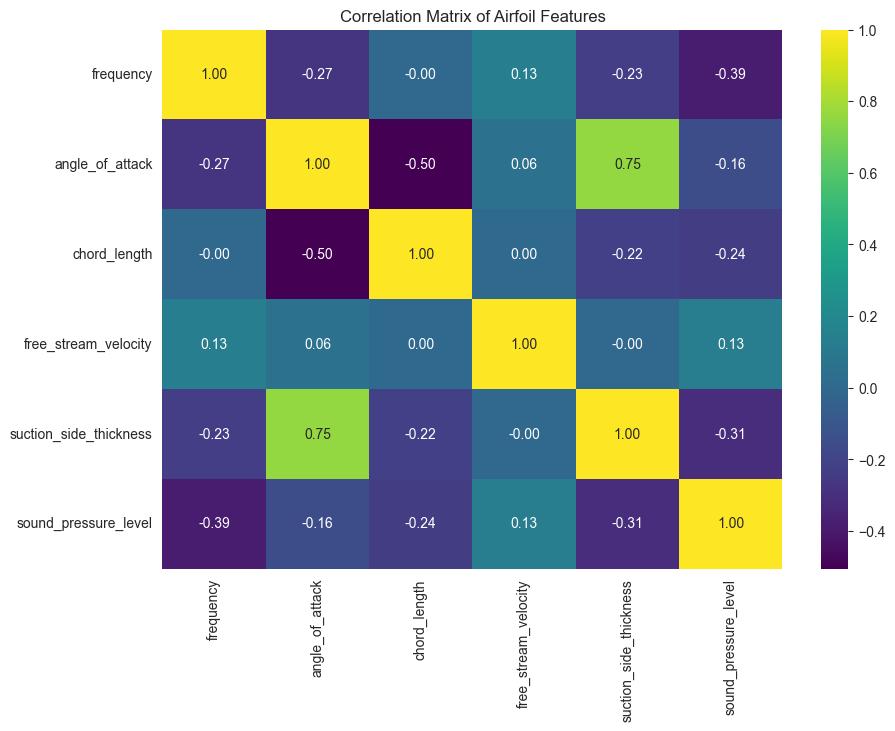

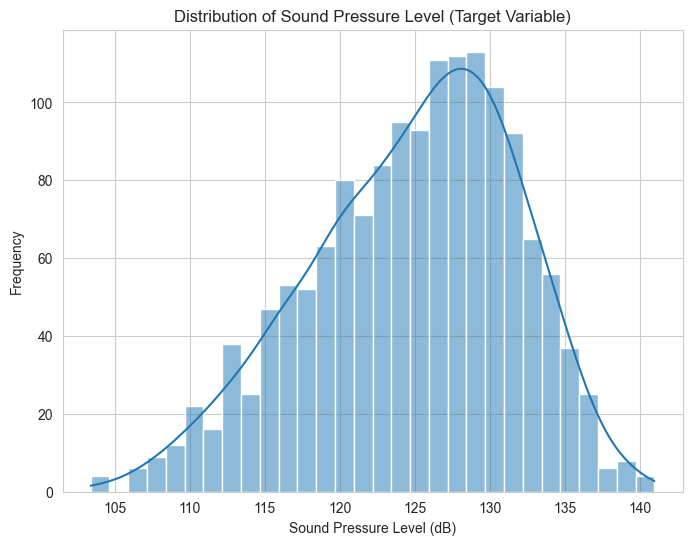

Training set size: 1202 samples
Testing set size: 301 samples

--- Model Coefficients ---
Intercept: 132.5315974058018
                        Coefficient
frequency                 -0.001272
angle_of_attack           -0.405660
chord_length             -34.469438
free_stream_velocity       0.098021
suction_side_thickness  -139.460274


--- Model Evaluation ---
Mean Absolute Error (MAE): 3.67
Mean Squared Error (MSE): 22.13
Root Mean Squared Error (RMSE): 4.70
R-squared (R²): 0.56




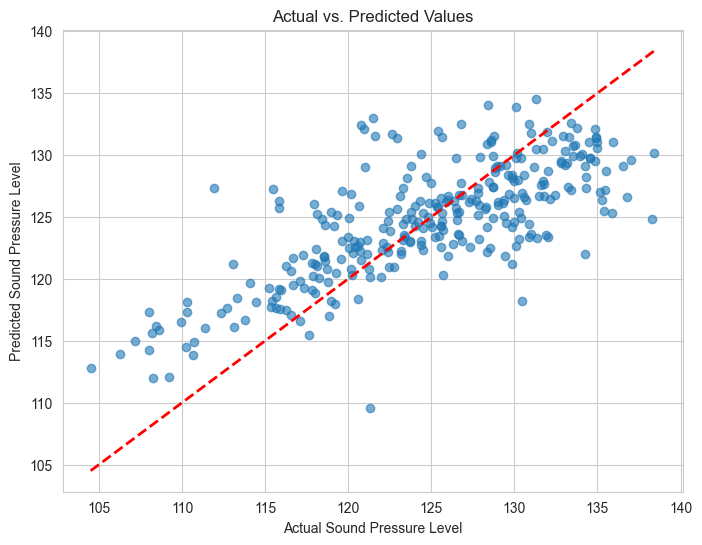

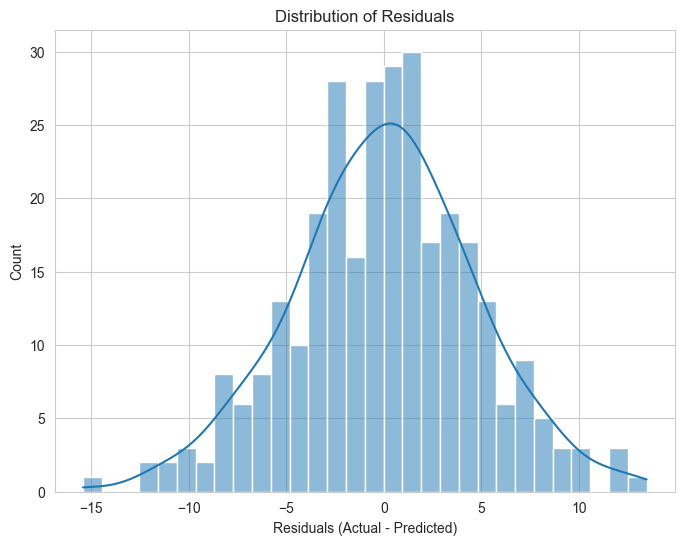

In [61]:
# Step 1: Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Set plot style for better visuals
sns.set_style('whitegrid')

# Step 2: Load and Prepare the Data
# The dataset is tab-separated and does not have a header row.
# We will provide column names based on the dataset's documentation.
column_names = [
    'frequency',
    'angle_of_attack',
    'chord_length',
    'free_stream_velocity',
    'suction_side_thickness',
    'sound_pressure_level'
]

# Load the data from the 'airfoil_self_noise.dat' file
try:
    df = pd.read_csv('airfoil_self_noise.dat', sep='\t', header=None, names=column_names)
except FileNotFoundError:
    print("Error: 'airfoil_self_noise.dat' not found. Make sure the file is in the same directory as the script.")
    exit()


# Step 3: Exploratory Data Analysis (EDA)

# Display the first 5 rows of the dataframe
print("--- Data Head ---")
print(df.head())
print("\n")

# Get a concise summary of the dataframe
print("--- Data Info ---")
df.info()
print("\n")

# Get descriptive statistics
print("--- Descriptive Statistics ---")
print(df.describe())
print("\n")

# Check for any missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())
print("\n")

# Visualize the correlation between features
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Airfoil Features')
plt.show()

# Visualize the distribution of the target variable (Sound Pressure Level)
plt.figure(figsize=(8, 6))
sns.histplot(df['sound_pressure_level'], kde=True, bins=30)
plt.title('Distribution of Sound Pressure Level (Target Variable)')
plt.xlabel('Sound Pressure Level (dB)')
plt.ylabel('Frequency')
plt.show()


# Step 4: Prepare Data for Modeling

# Define features (X) and the target variable (y)
X = df.drop('sound_pressure_level', axis=1)
y = df['sound_pressure_level']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")


# Step 5: Train the Linear Regression Model

# Create an instance of the LinearRegression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Print the model's coefficients and intercept
print("--- Model Coefficients ---")
print(f"Intercept: {model.intercept_}")
coeffs = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeffs)
print("\n")


# Step 6: Evaluate the Model

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')
print("\n")


# Step 7: Visualize the Results

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
# Plot a line for perfect predictions (y_test = y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Sound Pressure Level')
plt.ylabel('Predicted Sound Pressure Level')
plt.title('Actual vs. Predicted Values')
plt.show()

# Plot the distribution of the residuals (errors)
# A good model should have residuals that are normally distributed around zero.
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residuals (Actual - Predicted)')
plt.title('Distribution of Residuals')
plt.show()